# Check Milo Results

In [1]:
# Libraries
import os
import time
import scanpy as sc
from pathlib import Path
import rapids_singlecell as rsc
import pertpy as pt
import matplotlib.pyplot as plt
import numpy as np
import mudata as mu


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(
    p for p in Path.cwd().parents
    if (p / MAIN_DIR_NAME).exists()
) / MAIN_DIR_NAME

os.chdir(MAIN_DIR)


In [8]:
# call Milo
milo = pt.tl.Milo()

In [3]:
NICHE_NAME = 'BALT'
milo_dir = MAIN_DIR / "data" / 'niches' / NICHE_NAME / 'h5mu' / 'mdata.h5mu'
mdata = mu.read_h5mu(milo_dir)

In [4]:
mdata

MuData object with n_obs × n_vars = 76634 × 2000
  2 modalities
    rna:	76634 x 2000
      obs:	'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_6', 'niches_k_7', 'niches_k_8', 'niches_k_9', 'niches_k_10', 'niches_k_11', 'niche_name', 'cluster_cellcharter_k2', 'cluster_cellcharter_k3', 'cluster_cellcharter_k4', 'cluster_cellcharter_k5', 'cluster_cellcharter_k6', 'cluster_cellcharter_k7', 'cluster_cellcharter_k8', 'cluster_cellcharter_k9', 'cluster_cellcharter_k10', 'cluster_cellcharter', 'kmeans_niche', 'cellcharter_niche', 'kmeans_niches', 'cellcharter_niches', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'ann_lvl_1_colors', 'ann_lvl_2_colors', 'ann_lvl_3_colors', 'ann_lvl_3_refined_colors', 'cellcharter_niches_colors', 'donor_colors', 'hvg', 'kmeans_niches_colors', 'leiden_resolvi', 'leiden_resolvi_1.0_colors', 'log1p', 'nb_resolvi', 'nb_unint', 'neighbors', 'nhood_neighbors_key', 'niche_name_colors', 'pca', 'run_colors', 'sample_name_colors', 'slide_name_colors', 'spatial_neighbors', 'umap_resolvi', 'umap_unint'
      obsm:	'X_cellcharter', 'X_pca', 'X_resolvi', 'X_spatial', 'X_spatial_offset', 'X_umap', '_scvi_extra_categorical_covs', 'distance_neighbor', 'index_neighbor', 'nhoods', 'spatial', 'umap_resolvi', 'umap_unint'
      varm:	'PCs'
      layers:	'counts', 'resolvi_normalized'
      obsp:	'connectivities', 'distances', 'nb_resolvi_connectivities', 'nb_resolvi_distances', 'nb_unint_connectivities', 'nb_unint_distances', 'spatial_connectivities', 'spatial_distances'
    milo:	0 x 0

In [5]:
mdata["rna"][mdata["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
cell_id,,
SLIDE04_2100,1,3.636011
SLIDE04_2901,1,3.769491
SLIDE04_2921,1,2.992907
SLIDE04_2923,1,3.276739
SLIDE04_2940,1,4.024040
...,...,...
SLIDE02_412766,1,2.744859
SLIDE02_412929,1,3.316644
SLIDE02_412958,1,2.706149


Text(0, 0.5, '# nhoods')

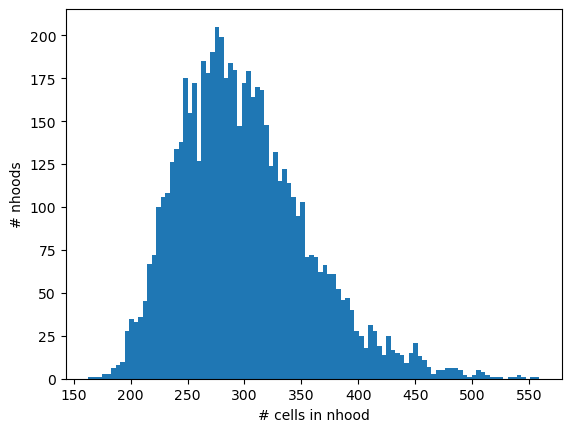

In [6]:
nhood_size = np.array(mdata["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

# Count cells in neighborhoods

In [9]:
mdata = milo.count_nhoods(mdata, sample_col="sample_name")

In [10]:
mdata

MuData object with n_obs × n_vars = 76634 × 2000
  2 modalities
    rna:	76634 x 2000
      obs:	'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_6', 'niches_k_7', 'niches_k_8', 'niches_k_9', 'niches_k_10', 'niches_k_11', 'niche_name', 'cluster_cellcharter_k2', 'cluster_cellcharter_k3', 'cluster_cellcharter_k4', 'cluster_cellcharter_k5', 'cluster_cellcharter_k6', 'cluster_cellcharter_k7', 'cluster_cellcharter_k8', 'cluster_cellcharter_k9', 'cluster_cellcharter_k10', 'cluster_cellcharter', 'kmeans_niche', 'cellcharter_niche', 'kmeans_niches', 'cellcharter_niches', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'ann_lvl_1_colors', 'ann_lvl_2_colors', 'ann_lvl_3_colors', 'ann_lvl_3_refined_colors', 'cellcharter_niches_colors', 'donor_colors', 'hvg', 'kmeans_niches_colors', 'leiden_resolvi', 'leiden_resolvi_1.0_colors', 'log1p', 'nb_resolvi', 'nb_unint', 'neighbors', 'nhood_neighbors_key', 'niche_name_colors', 'pca', 'run_colors', 'sample_name_colors', 'slide_name_colors', 'spatial_neighbors', 'umap_resolvi', 'umap_unint'
      obsm:	'X_cellcharter', 'X_pca', 'X_resolvi', 'X_spatial', 'X_spatial_offset', 'X_umap', '_scvi_extra_categorical_covs', 'distance_neighbor', 'index_neighbor', 'nhoods', 'spatial', 'umap_resolvi', 'umap_unint'
      varm:	'PCs'
      layers:	'counts', 'resolvi_normalized'
      obsp:	'connectivities', 'distances', 'nb_resolvi_connectivities', 'nb_resolvi_distances', 'nb_unint_connectivities', 'nb_unint_distances', 'spatial_connectivities', 'spatial_distances'
    milo:	12 x 6266
      var:	'index_cell', 'kth_distance'
      uns:	'sample_col'

In [11]:
mdata['milo']

AnnData object with n_obs × n_vars = 12 × 6266
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

# Differential Abundance testing

## CF vs CTRL

In [12]:
# Reorder categories (by default, the last category is taken as the condition of interest)
mdata["rna"].obs["condition"] = mdata["rna"].obs["condition"].cat.reorder_categories(["CTRL", "CF_ETI", "CF"])


In [13]:
# taking run+condition into account
milo.da_nhoods(
    mdata,
    design="~run+condition",
    model_contrasts="conditionCF-conditionCTRL",
    solver="pydeseq2",
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.21 seconds.

Fitting dispersion trend curve...
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.11 seconds.

Fitting MAP dispersions...
... done in 1.15 seconds.

Fitting LFCs...
... done in 1.22 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition CF vs CTRL
       baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0      6.723986       -0.123408  1.392110 -0.088648  0.929361  0.968735
1      8.434473       -1.000100  1.321909 -0.756557  0.449315  0.697056
2      6.901992        2.723909  1.241492  2.194061  0.028231  0.370663
3      6.508416        1.783364  1.311151  1.360151  0.173782  0.467727
4      5.342198        1.194453  1.181065  1.011335  0.311856  0.589027
...         ...             ...       ...       ...       ...       ...
6261   5.574001        2.830028  1.514982  1.868027  0.061758  0.371153
6262  10.591860        0.563445  1.100492  0.511994  0.608655  0.806700
6263   5.456660        2.631700  1.439061  1.828762  0.067435  0.371153
6264   7.561536        1.285209  1.849390  0.694937  0.487095  0.725490
6265   5.705081        1.612990  1.350631  1.194249  0.232380  0.519107

[6266 rows x 6 columns]


... done in 1.38 seconds.



In [14]:
mdata["milo"].obs

,run,condition,sample_name
CTRL01,RUN03,CTRL,CTRL01
CTRL02,RUN03,CTRL,CTRL02
CTRL03,RUN03,CTRL,CTRL03
CTRL04,RUN03,CTRL,CTRL04
CTRL05,RUN03,CTRL,CTRL05
PWCF01_1,RUN01,CF,PWCF01_1
PWCF01_2,RUN01,CF,PWCF01_2
PWCF02,RUN02,CF,PWCF02
PWCF03,RUN02,CF,PWCF03
PWCF04,RUN02,CF_ETI,PWCF04


In [14]:
mdata["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,SLIDE04_3294,5.618661,16.619586,-3.246099,0.013025,0.045076,0.090995
1,SLIDE04_4070,2.212748,10.736042,3.012033,0.079829,NaN,0.223863
2,SLIDE04_4087,2.823781,8.302488,1.238187,0.296731,NaN,0.483927
3,SLIDE04_4098,2.295154,7.974661,3.431864,0.026576,NaN,0.122891
4,SLIDE04_8626,2.043111,19.047739,-0.413326,0.682437,0.776937,0.801799
...,...,...,...,...,...,...,...
19425,SLIDE02_424908,3.106962,7.989925,-1.451311,0.215431,NaN,0.395644
19426,SLIDE02_424916,3.690792,12.016374,-0.008034,0.994669,NaN,0.997137
19427,SLIDE02_424917,4.802320,22.086418,-2.858139,0.004124,0.019025,0.063119
19428,SLIDE02_425035,2.778755,14.521475,-1.520532,0.151728,0.269149,0.319954


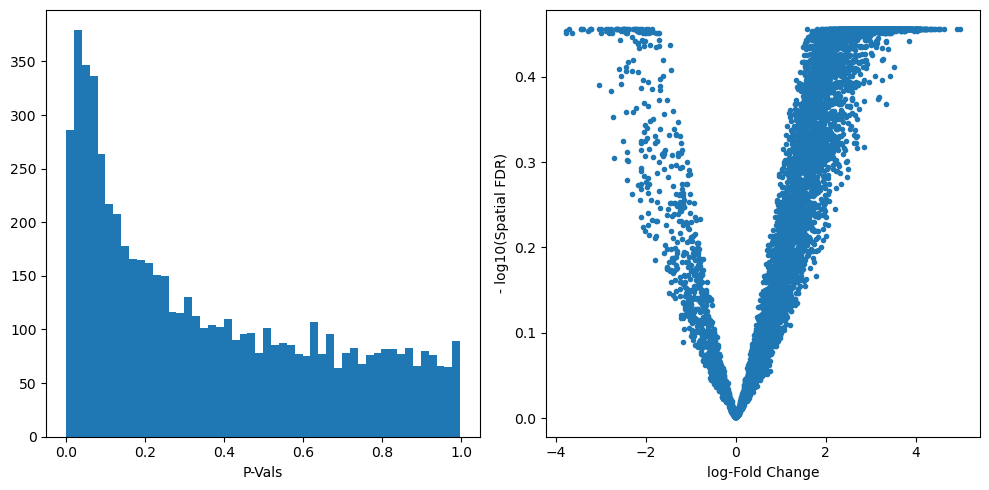

In [15]:
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata["milo"].var.logFC, -np.log10(mdata["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

In [17]:
milo.build_nhood_graph(mdata)

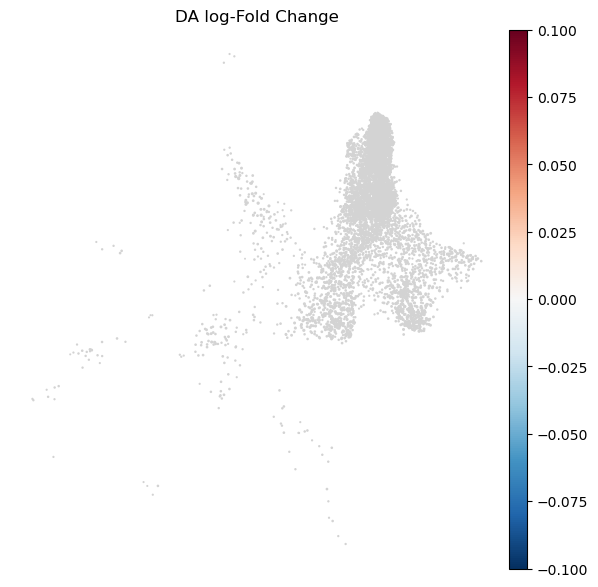

In [18]:
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata,
    padj_threshold=0.1,  # SpatialFDR level (1%)
    min_size=0.05,  # Size of smallest dot
)

### Visualize result by CELL TYPE

In [19]:
milo.annotate_nhoods(mdata, anno_col="ann_lvl_3_refined")

Text(0.5, 0, 'celltype fraction')

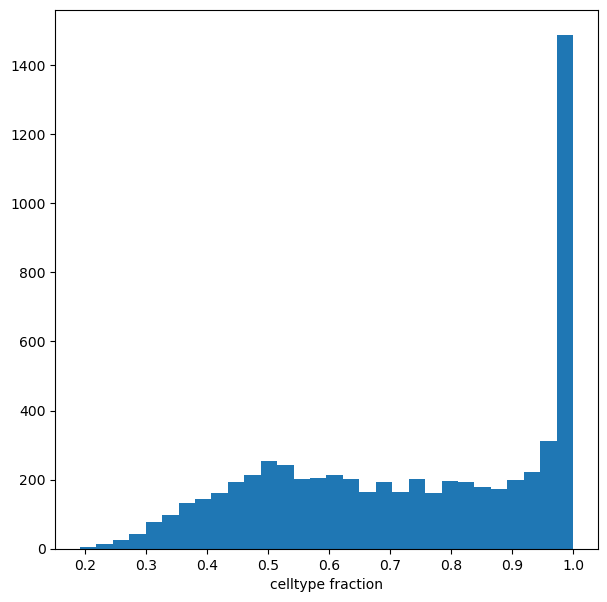

In [20]:
plt.hist(mdata["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [21]:
for cutoff in [0.5, 0.6, 0.7, 0.8, 0.9]:
    frac_mixed = (
        mdata["milo"].var["nhood_annotation_frac"] < cutoff
    ).mean()

    print(cutoff, frac_mixed)

0.5 0.19294605809128632
0.6 0.3247685924034472
0.7 0.43919565911267155
0.8 0.5432492818384934
0.9 0.6552824768592403


In [22]:
mdata["milo"].var["nhood_annotation"] = mdata["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata["milo"].var.loc[mdata["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

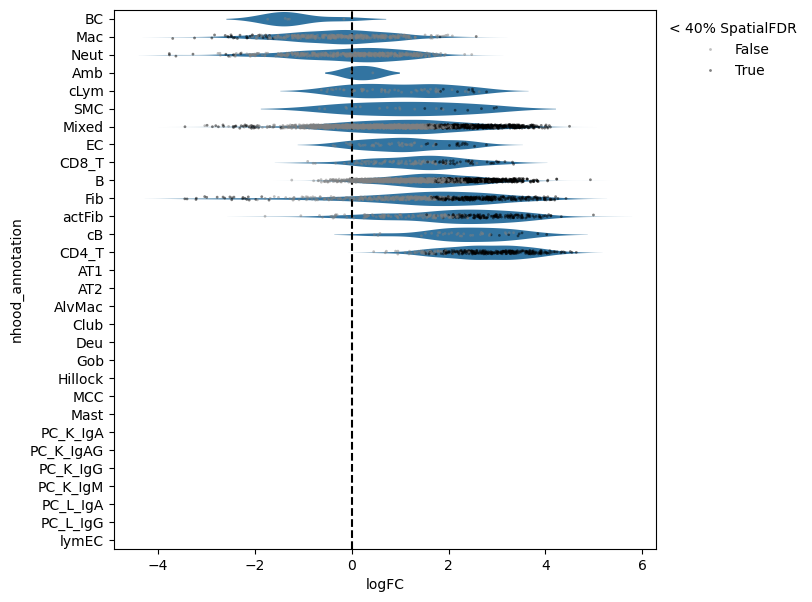

In [29]:
milo.plot_da_beeswarm(mdata, padj_threshold=0.4)

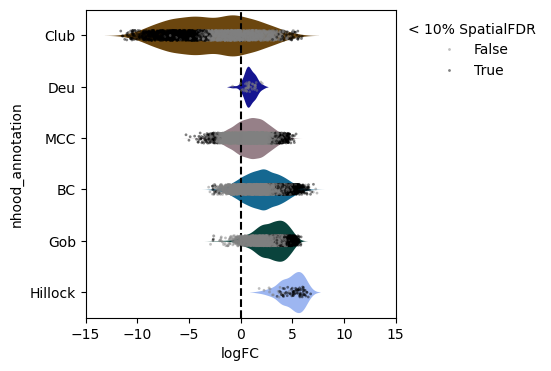

In [35]:
# only airway cell types
celltypes_to_show = [
    "Club",
    "Gob",
    "BC",
    "MCC",
    "Deu",
    "Hillock"
]


fig = milo.plot_da_beeswarm(
    mdata,
    subset_nhoods=celltypes_to_show,
    padj_threshold=0.1,
    return_fig=True
)

fig.set_size_inches(4, 4)

# Limit logFC axis
ax = fig.axes[0]
ax.set_xlim(-15, 15)

out_dir = Path(
    f"/mnt/data/project0062/proseg_data/results/niches/{NICHE_NAME}/da_ct"
)
out_dir.mkdir(parents=True, exist_ok=True)

for ext in ["png", "svg", "pdf"]:
    fig.savefig(
        out_dir / f"milo_beeswarm_CF_vs_CTRL.{ext}",
        dpi=900,
        bbox_inches="tight"
    )

nhood_annotation
Club         1110
BC            796
Gob           688
MCC           418
Hillock        64
Amb            50
Fib            34
AT2            31
Mac            26
SMC            11
actFib         11
EC              9
Neut            9
AT1             5
Mast            4
AlvMac          1
cLym            1
B               0
CD8_T           0
CD4_T           0
Deu             0
PC_K_IgA        0
PC_K_IgM        0
PC_K_IgG        0
PC_K_IgAG       0
PC_L_IgG        0
PC_L_IgA        0
cB              0
lymEC           0
Mixed           0
Name: count, dtype: int64
['Club', 'BC', 'Gob', 'MCC', 'Hillock', 'Amb', 'Fib', 'AT2', 'Mac', 'SMC', 'actFib']


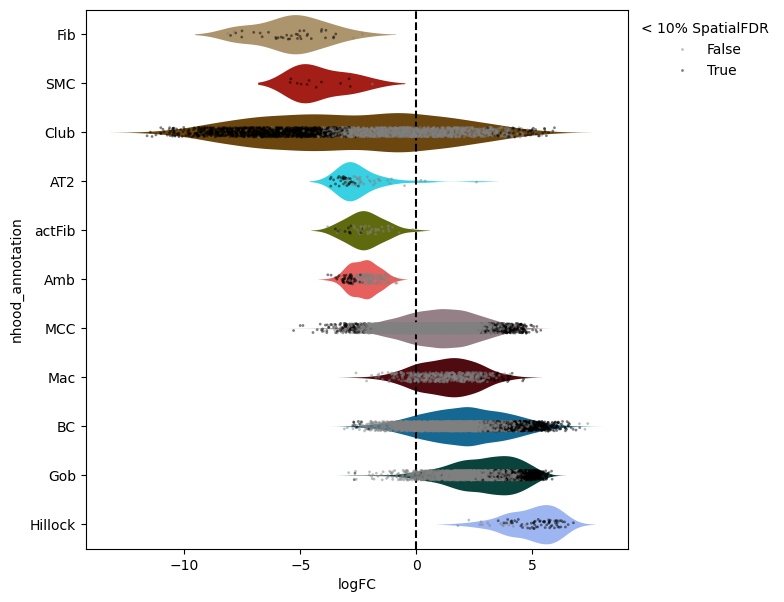

In [27]:
milo_res = mdata["milo"].var

# Count significant neighbourhoods per cell type
sig_counts = (
    milo_res.loc[
        (milo_res["SpatialFDR"] < 0.1)
        & (milo_res["nhood_annotation"] != "Mixed"),
        "nhood_annotation"
    ]
    .value_counts()
)

# Keep cell types with at least 10 significant neighbourhoods
celltypes_to_show = sig_counts[
    sig_counts >= 10
].index.tolist()

print(sig_counts)
print(celltypes_to_show)

fig = milo.plot_da_beeswarm(
    mdata,
    padj_threshold=0.1,
    subset_nhoods=celltypes_to_show,
    return_fig=True,
)

In [41]:
milo_res = mdata["milo"].var

milo_res.sort_values("logFC").head(20)[
    ["nhood_annotation", "logFC", "SpatialFDR"]
]

,nhood_annotation,logFC,SpatialFDR
87281,Mac,-31.749081,0.894702
88269,AlvMac,-19.862071,0.793360
44273,Fib,-12.700203,0.034234
88189,Fib,-12.661769,0.002095
40484,Fib,-12.604520,0.006694
39356,Fib,-12.587345,0.007770
43658,EC,-12.488031,0.007241
44325,EC,-12.477871,1.000000
29246,AlvMac,-12.403676,0.004151
88470,Fib,-12.262706,0.004258


In [25]:
import pandas as pd
import numpy as np

res = mdata["milo"].var.copy()

# Significant DA neighbourhoods
sig = res[res["SpatialFDR"] < 0.1].copy()

# Direction using an absolute logFC threshold of 0

fold_thres = 0
sig["direction"] = np.select(
    [
        sig["logFC"] >= fold_thres,
        sig["logFC"] <= -fold_thres,
    ],
    [
        "Enriched in CF",
        "Depleted in CF",
    ],
    default="No strong change"
)

# Keep only significant neighbourhoods with |logFC| >= 1
sig_strong = sig[sig["logFC"].abs() >= 1].copy()

# Count significant + strong neighbourhoods in each direction
direction_counts = pd.crosstab(
    sig_strong["nhood_annotation"],
    sig_strong["direction"]
).reindex(
    columns=["Enriched in CF", "Depleted in CF"],
    fill_value=0
)

# Total number of neighbourhoods per cell type
total = (
    res.groupby("nhood_annotation", observed=True)
    .size()
    .rename("n_nhoods")
)

# Median logFC among significant + strong neighbourhoods
median_lfc = (
    sig_strong
    .groupby("nhood_annotation", observed=True)["logFC"]
    .median()
    .rename("median_logFC_sig")
)

# Combine, starting from total so all cell types are retained
summary = (
    total.to_frame()
    .join(direction_counts)
    .join(median_lfc)
)

# Cell types with no significant |logFC| >= 1 neighbourhoods
summary[["Enriched in CF", "Depleted in CF"]] = (
    summary[["Enriched in CF", "Depleted in CF"]]
    .fillna(0)
    .astype(int)
)

# Number of significant + strong neighbourhoods
summary["n_sig"] = (
    summary["Enriched in CF"] +
    summary["Depleted in CF"]
)

# Percentage of all neighbourhoods that are significant + strong
summary["pct_sig"] = (
    summary["n_sig"] /
    summary["n_nhoods"] * 100
)

# Overall direction for each cell type
summary["DA_direction"] = np.select(
    [
        summary["Enriched in CF"] > summary["Depleted in CF"],
        summary["Depleted in CF"] > summary["Enriched in CF"],
    ],
    [
        "Enriched in CF",
        "Depleted in CF",
    ],
    default="Mixed / no DA"
)

# Final table
summary_out = summary[
    [
        "n_nhoods",
        "n_sig",
        "pct_sig",
        "Enriched in CF",
        "Depleted in CF",
        "median_logFC_sig",
        "DA_direction",
    ]
].round(2)

# Order direction
summary_out["DA_direction"] = pd.Categorical(
    summary_out["DA_direction"],
    categories=[
        "Enriched in CF",
        "Depleted in CF",
        "Mixed / no DA",
    ],
    ordered=True,
)

# Group by direction, then strongest evidence within each group
summary_out = summary_out.sort_values(
    ["DA_direction", "pct_sig"],
    ascending=[True, False],
)

summary_out

,n_nhoods,n_sig,pct_sig,Enriched in CF,Depleted in CF,median_logFC_sig,DA_direction
nhood_annotation,,,,,,,
Hillock,79,64,81.01,64,0,5.43,Enriched in CF
Gob,2773,688,24.81,686,2,4.49,Enriched in CF
BC,4149,796,19.19,786,10,4.39,Enriched in CF
MCC,6058,418,6.90,312,106,3.51,Enriched in CF
Mac,433,26,6.00,26,0,3.50,Enriched in CF
cLym,18,1,5.56,1,0,3.82,Enriched in CF
Mast,172,4,2.33,4,0,3.93,Enriched in CF
AT1,5,5,100.00,0,5,-2.99,Depleted in CF
SMC,12,11,91.67,0,11,-4.62,Depleted in CF


####### PC_K_IgA #######


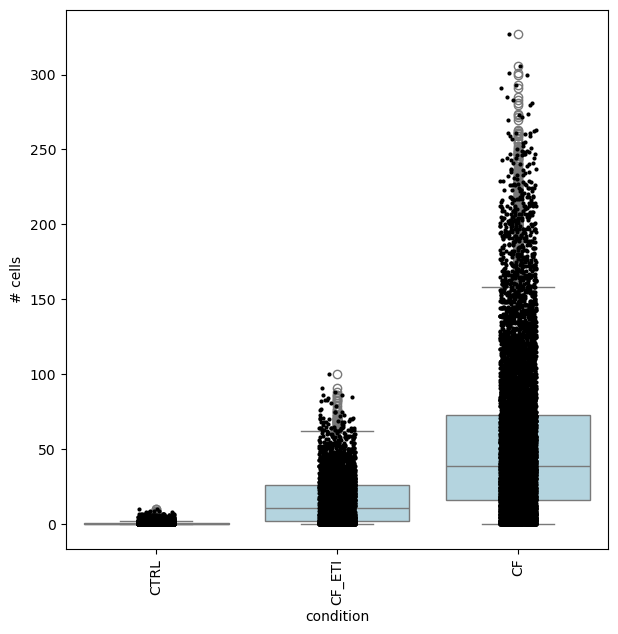

####### Fib #######


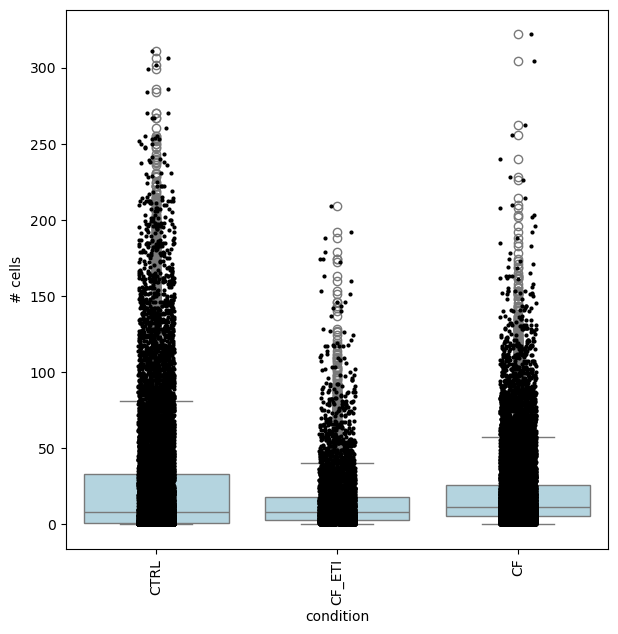

####### Neut #######


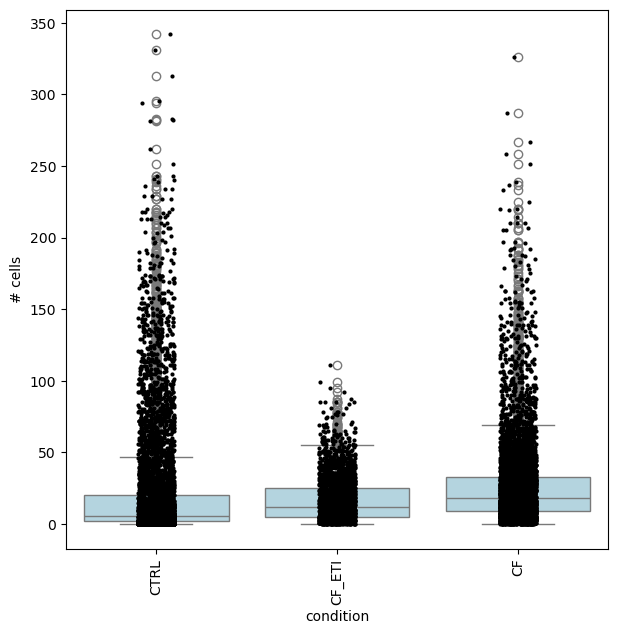

####### CD8_T #######


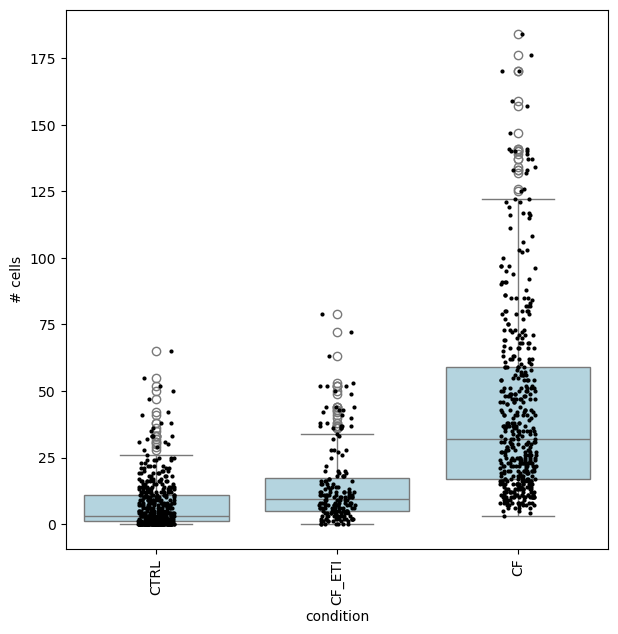

####### SMC #######


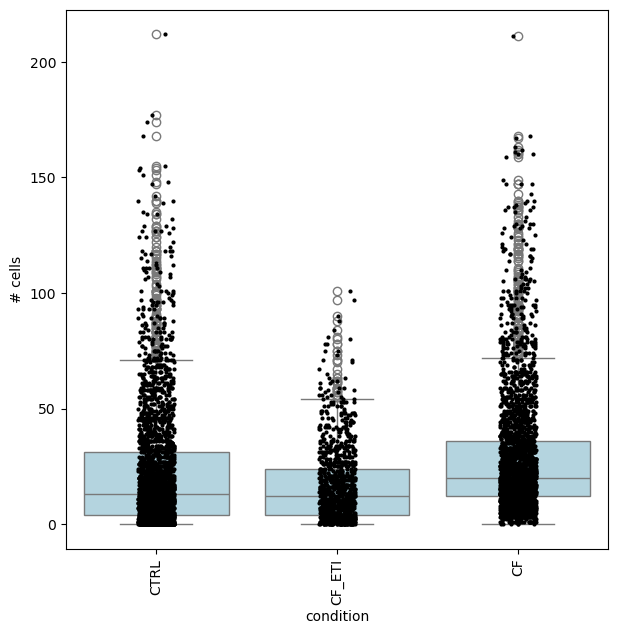

####### EC #######


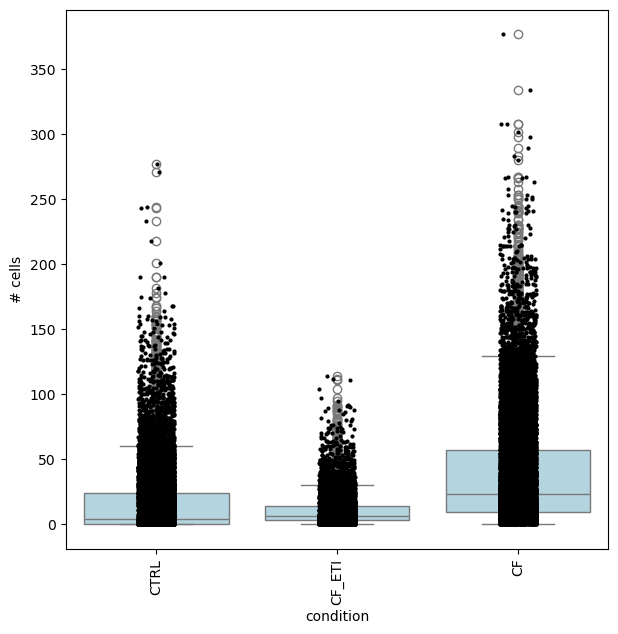

####### Amb #######


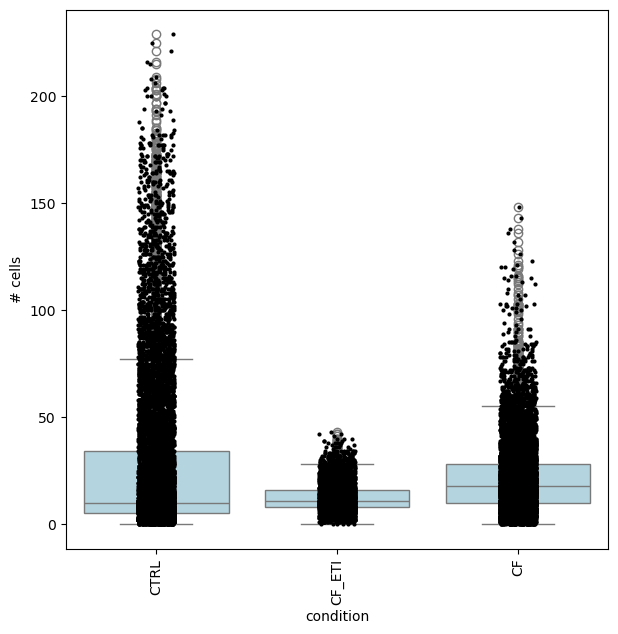

####### Mac #######


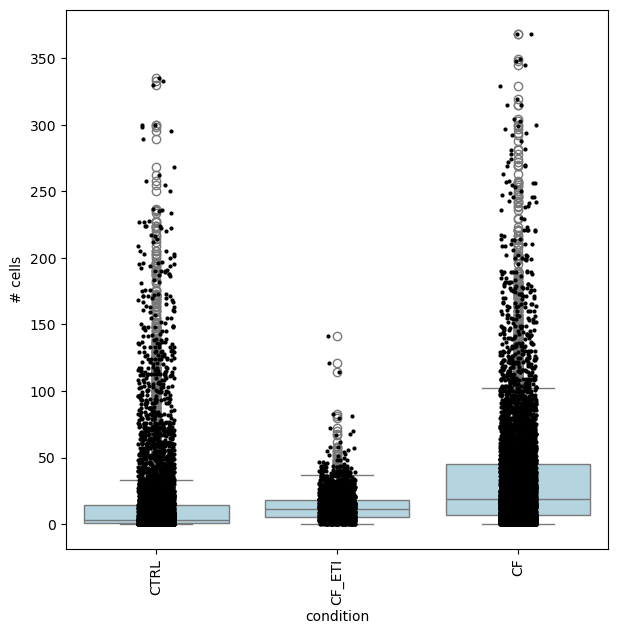

####### PC_L_IgA #######


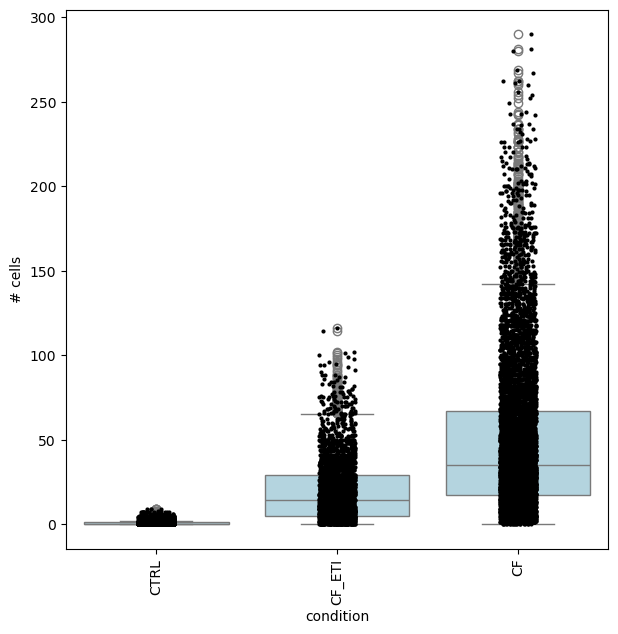

####### PC_L_IgG #######


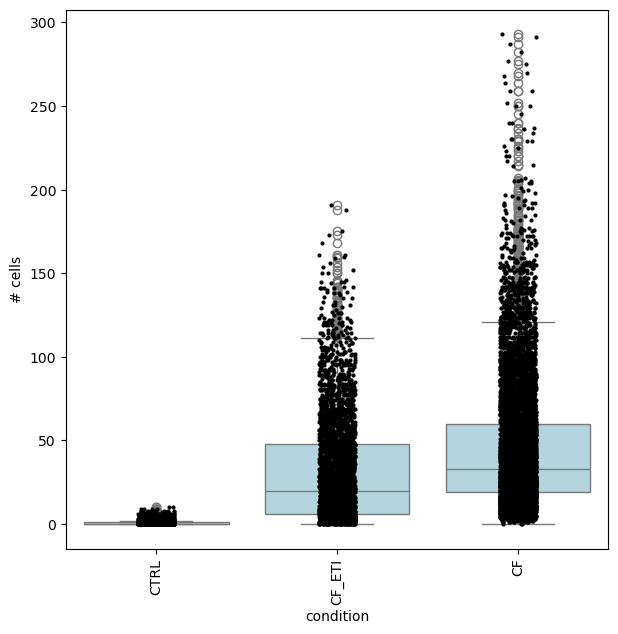

####### PC_K_IgAG #######


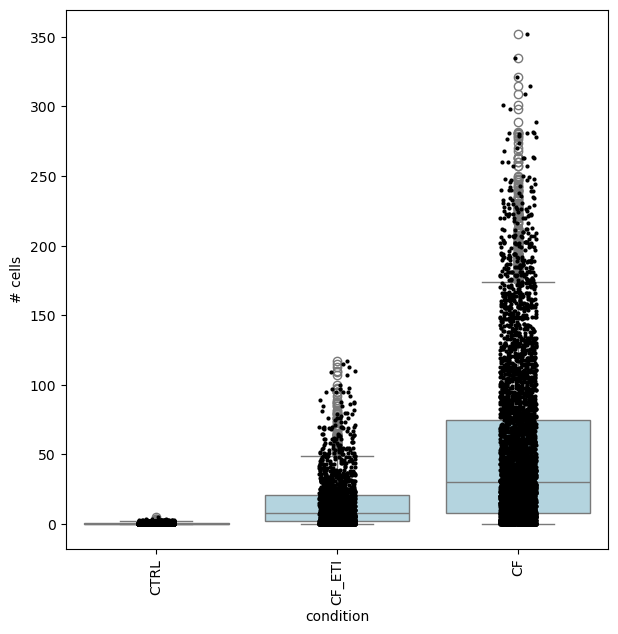

####### Mast #######


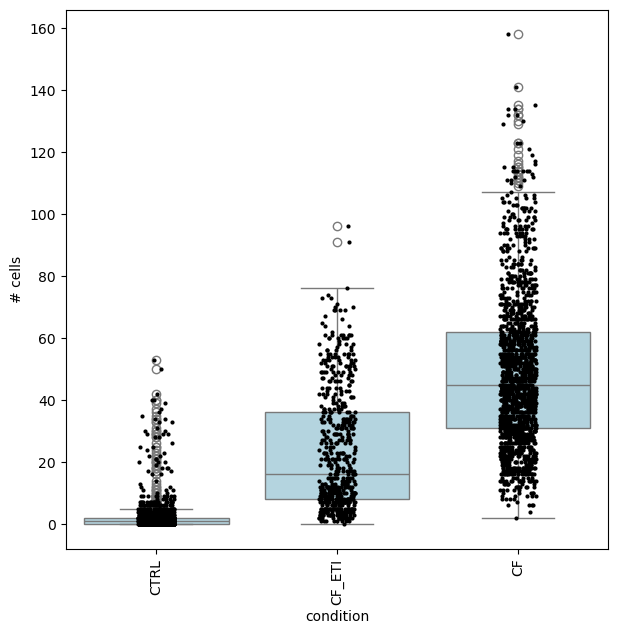

####### actFib #######


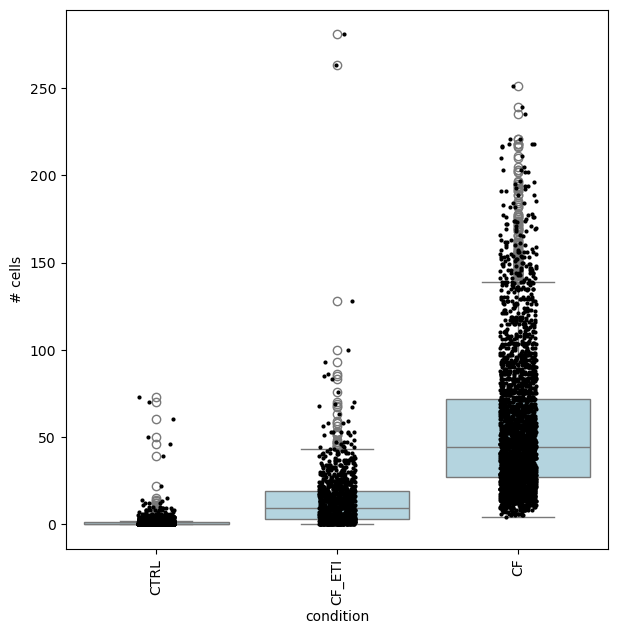

####### AT2 #######


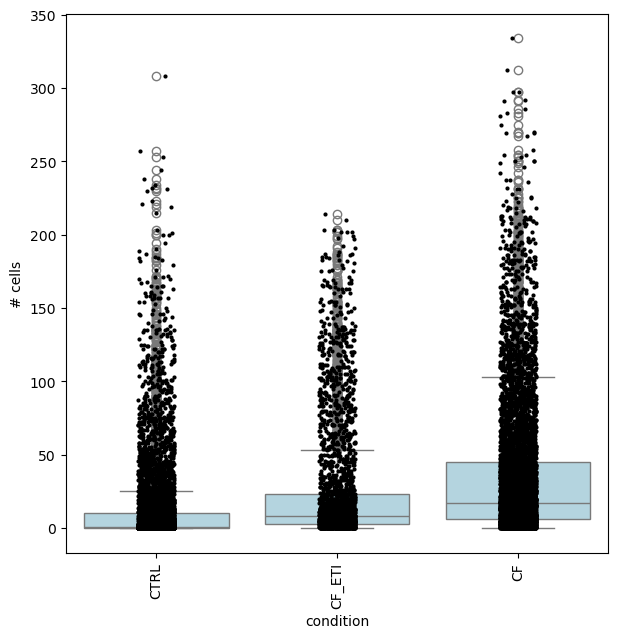

####### CD4_T #######


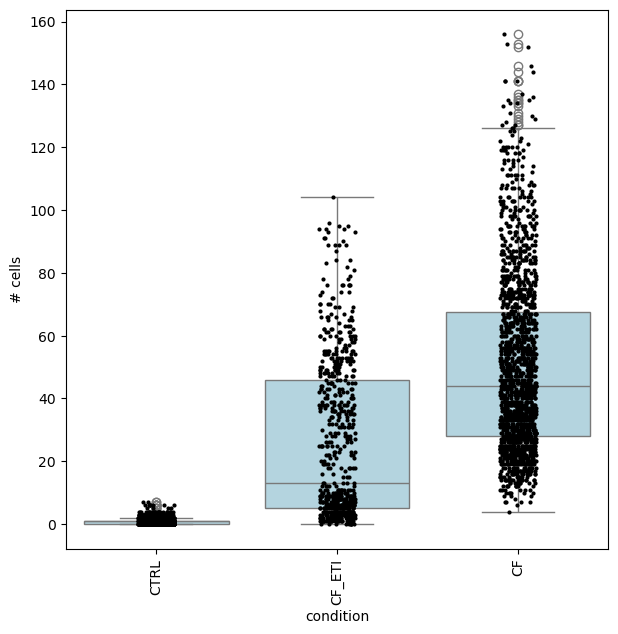

####### cLym #######


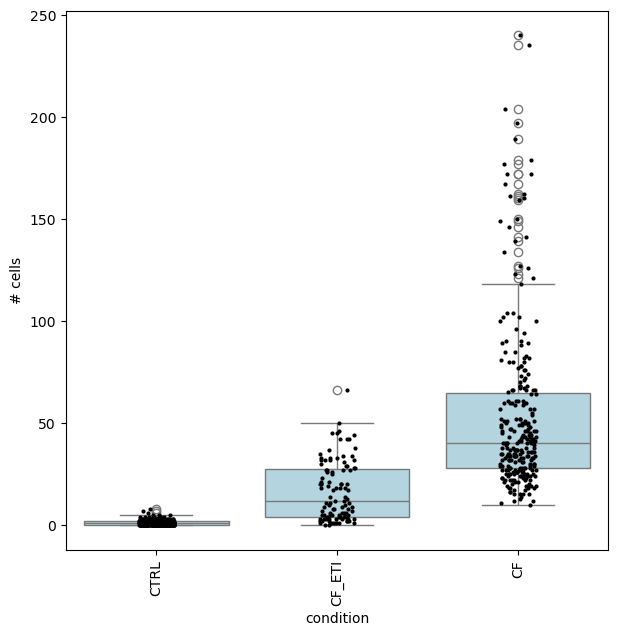

####### AlvMac #######


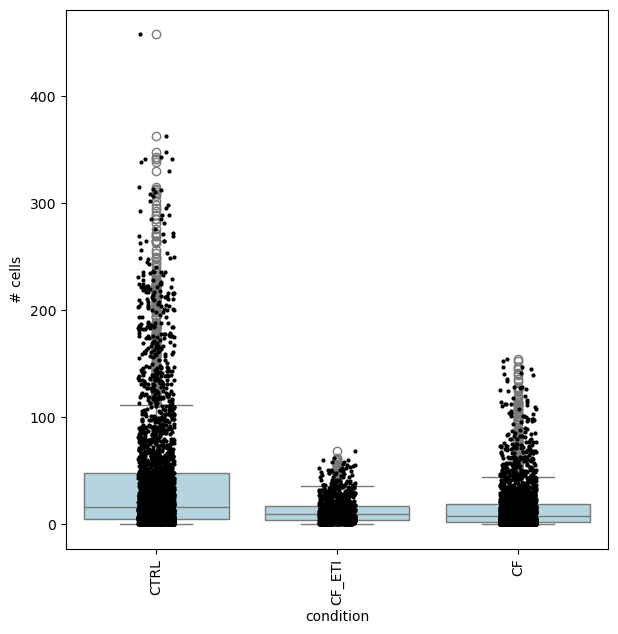

####### BC #######


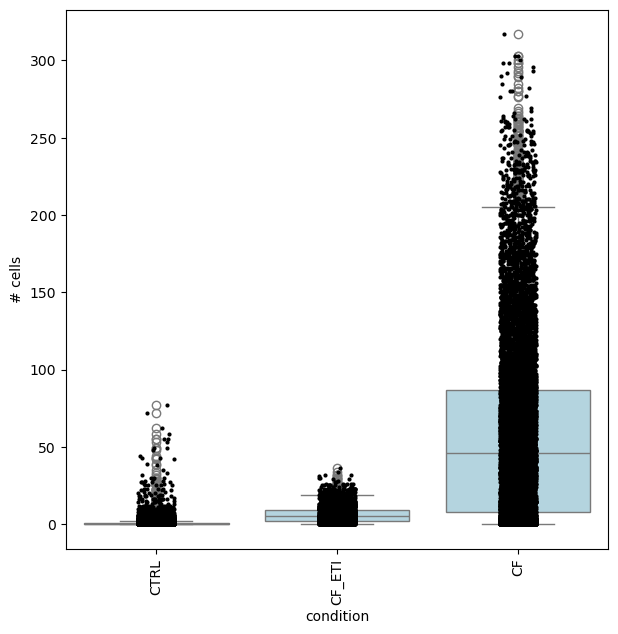

####### AT1 #######


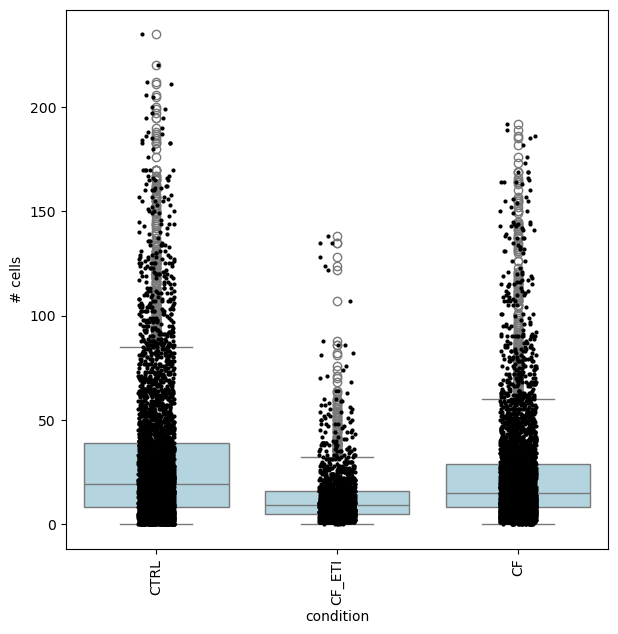

####### PC_K_IgG #######


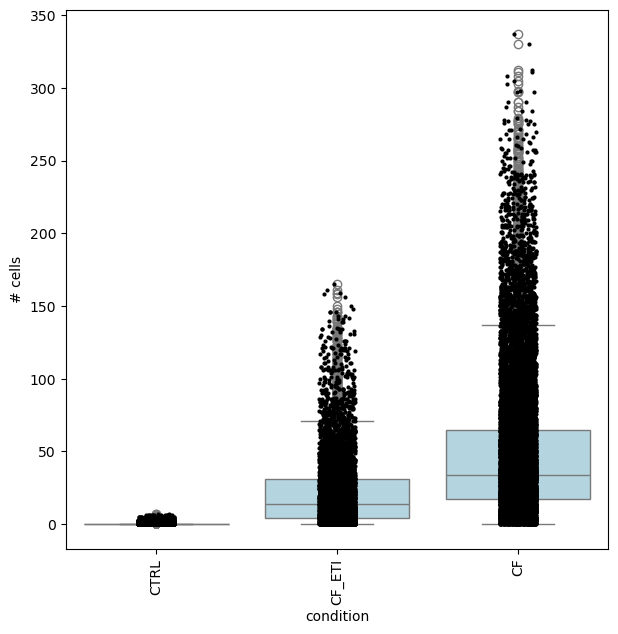

####### B #######


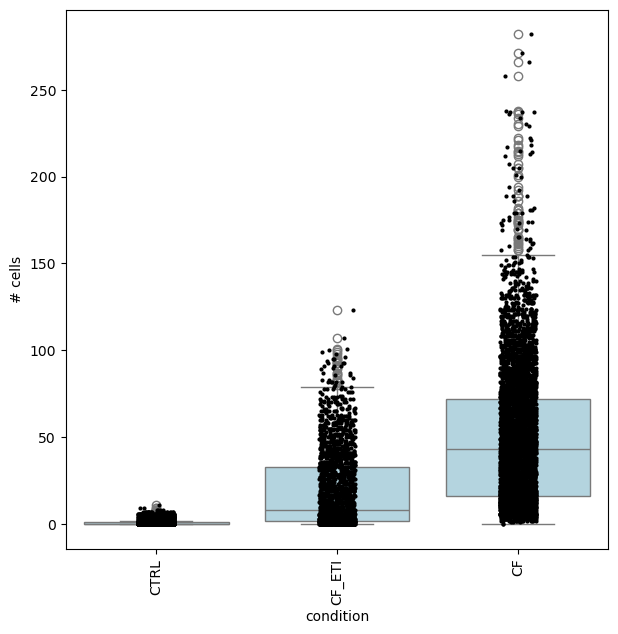

####### lymEC #######


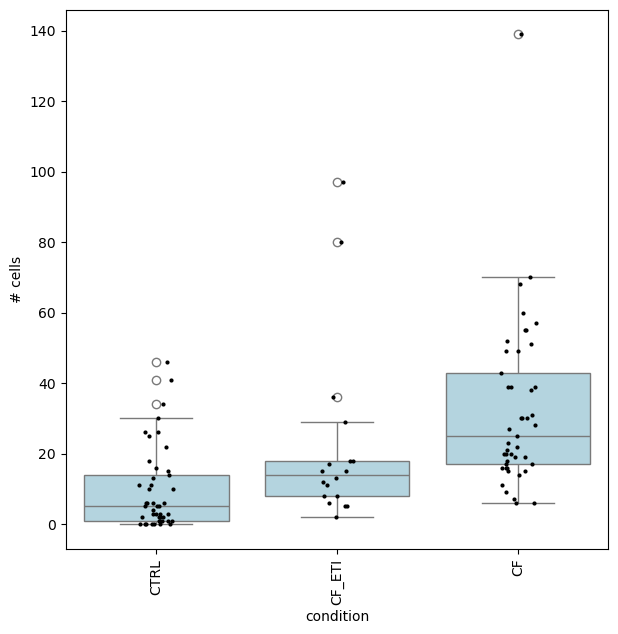

####### PC_K_IgM #######


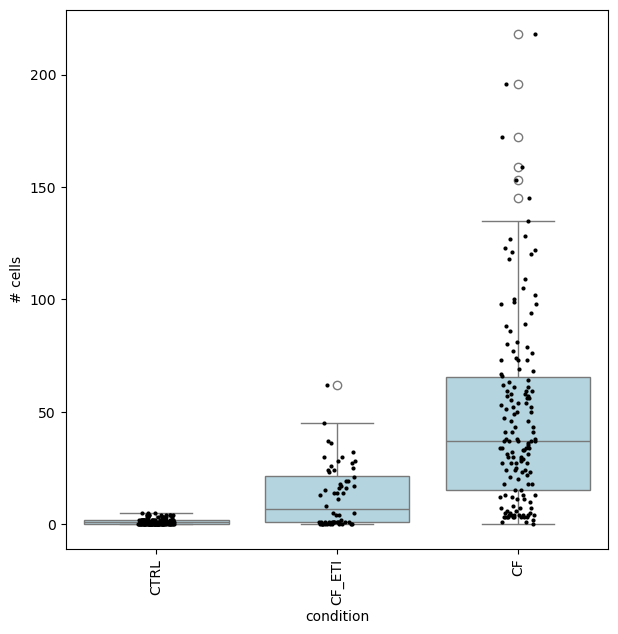

####### Club #######


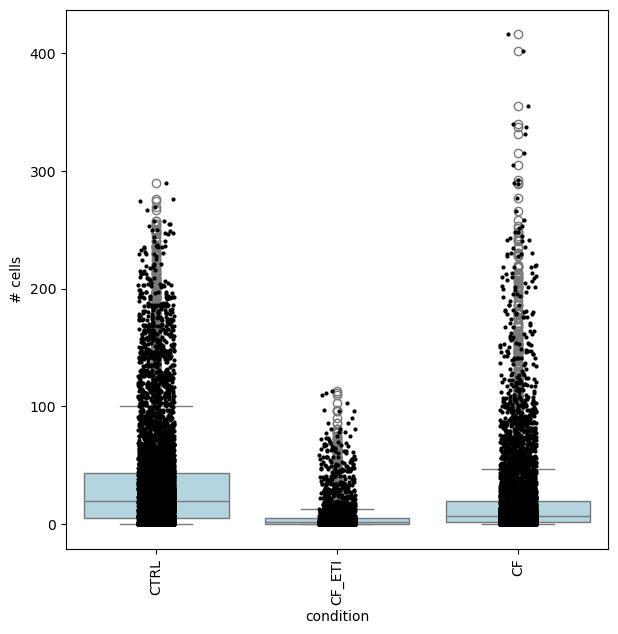

####### Gob #######


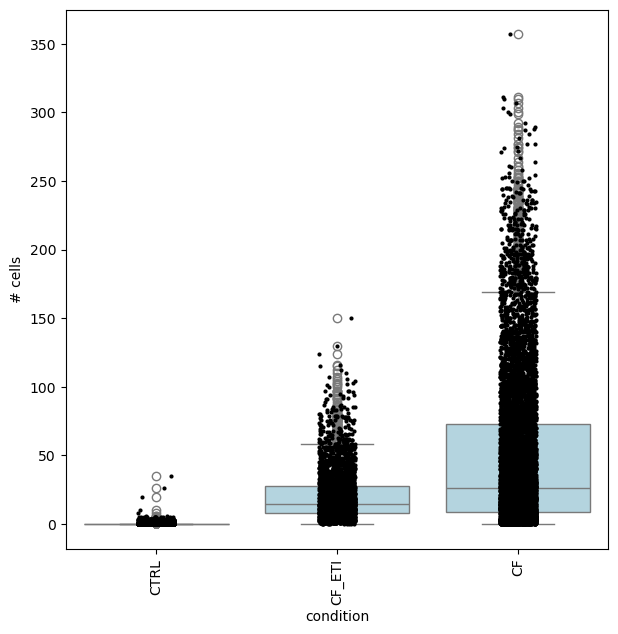

####### MCC #######


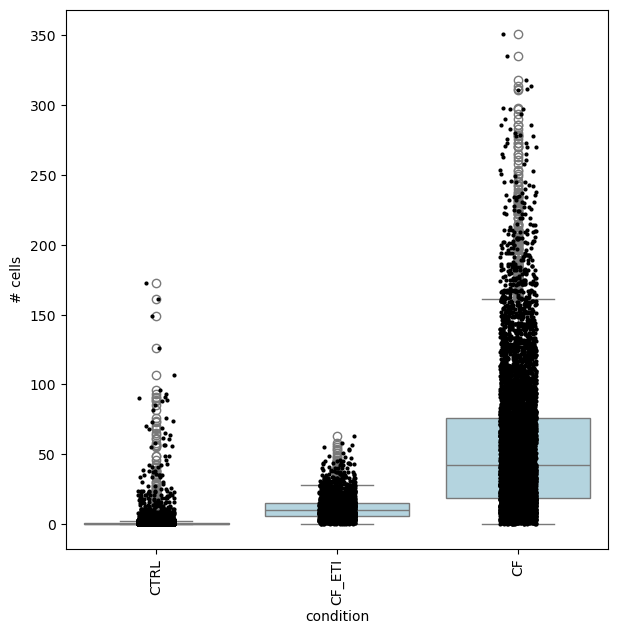

####### cB #######


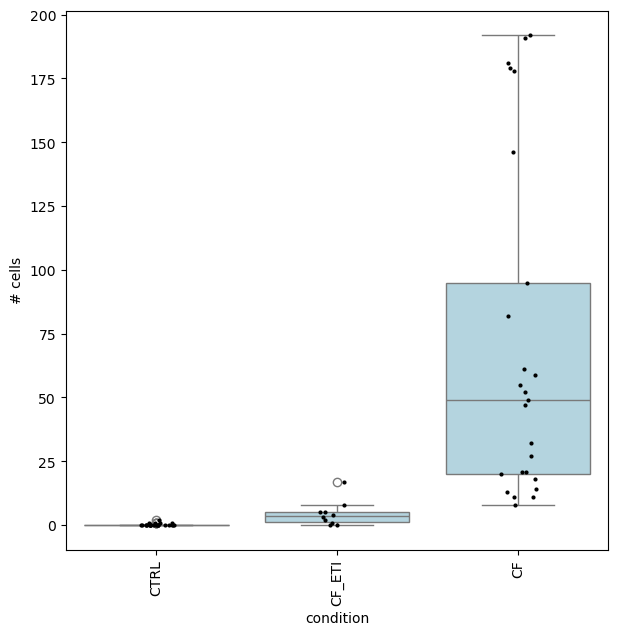

####### Hillock #######


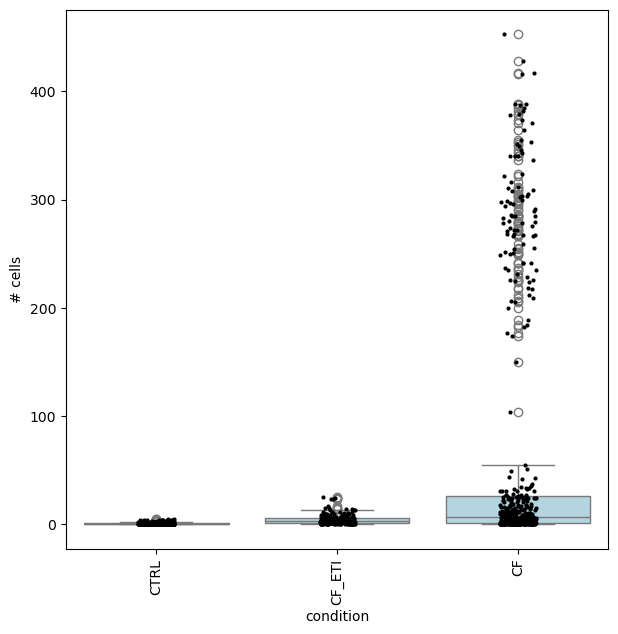

####### Deu #######


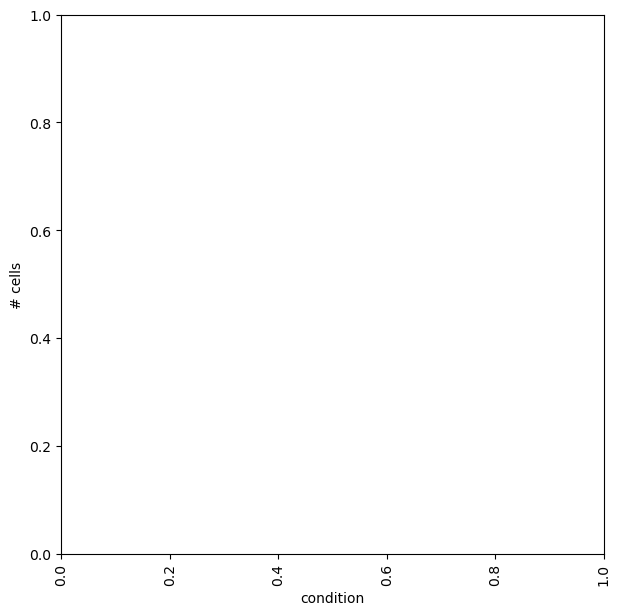

In [43]:
celltypes = mdata['rna'].obs['ann_lvl_3_refined'].unique().tolist()

for ct in celltypes:

    pl_nhoods = mdata["milo"].var_names[
        (mdata["milo"].var["SpatialFDR"] < 0.1) & (mdata["milo"].var["nhood_annotation"] == ct)
    ]
    
    ## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
    print(f'####### {ct} #######')
    milo.plot_nhood_counts_by_cond(mdata, test_var="condition", subset_nhoods=pl_nhoods, log_counts=False)

# Visualize result by NICHE

In [57]:
milo.annotate_nhoods(mdata, anno_col="niche_name")

Text(0.5, 0, 'celltype fraction')

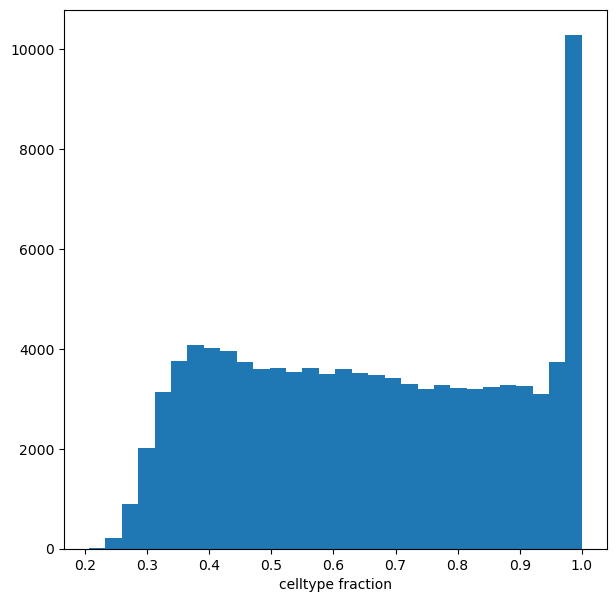

In [58]:
plt.hist(mdata["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [59]:
for cutoff in [0.5, 0.6, 0.7, 0.8, 0.9]:
    frac_mixed = (
        mdata["milo"].var["nhood_annotation_frac"] < cutoff
    ).mean()

    print(cutoff, frac_mixed)

0.5 0.2945142993137916
0.6 0.42884058545872833
0.7 0.560905953750347
0.8 0.682955852604022
0.9 0.8046785133473484


In [60]:
mdata["milo"].var["nhood_annotation"] = mdata["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata["milo"].var.loc[mdata["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

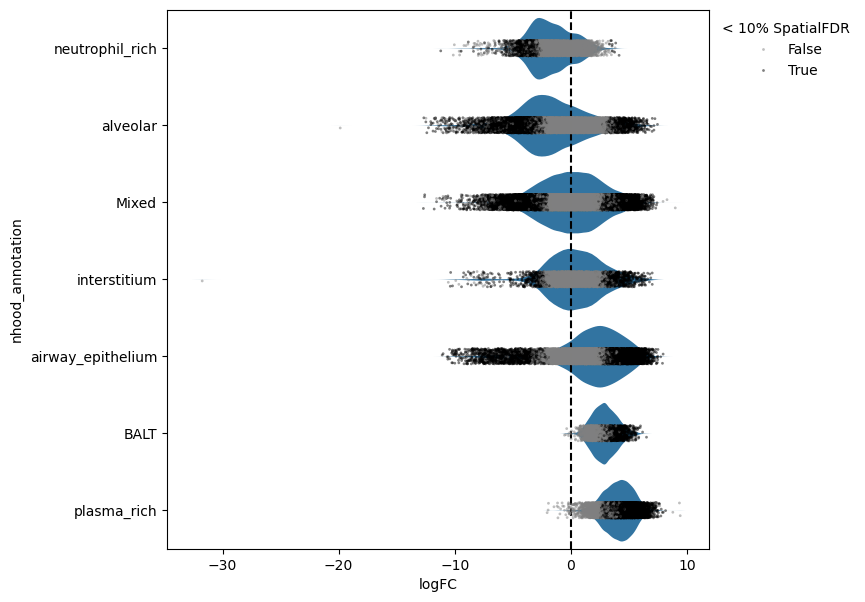

In [61]:
milo.plot_da_beeswarm(mdata, padj_threshold=0.1)

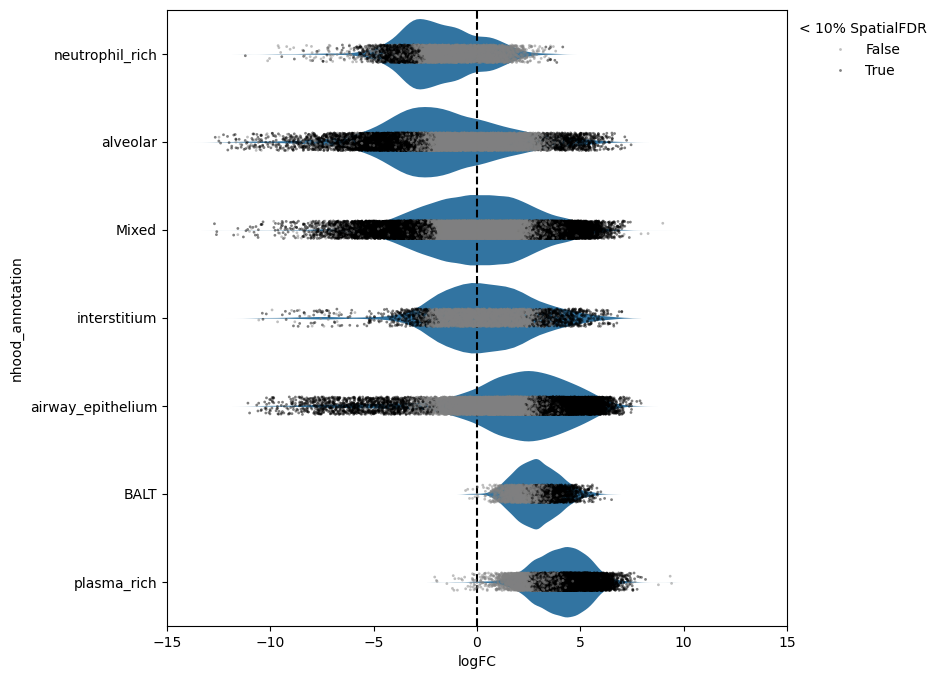

In [62]:
fig = milo.plot_da_beeswarm(
    mdata,
    padj_threshold=0.1,
    return_fig=True
)

fig.set_size_inches(8, 8)

# Limit logFC axis
ax = fig.axes[0]
ax.set_xlim(-15, 15)

out_dir = Path(
    "/mnt/data/project0062/proseg_data/results/comb/da_niche"
)
out_dir.mkdir(parents=True, exist_ok=True)

for ext in ["png", "svg"]:
    fig.savefig(
        out_dir / f"milo_beeswarm_CF_vs_CTRL.{ext}",
        dpi=900,
        bbox_inches="tight"
    )